# Analysis of the Trained pred prey model

In [3]:
import torch
import pickle
import numpy as np
from autoencoder_torch import full_network

# Load params used for training
timestamp = "2025_05_14_18_26_02_575880"
params_path = f"Results/predprey_{timestamp}_params.pkl"
model_path = f"Results/PredPrey_final.pt"
params = pickle.load(open(params_path, 'rb'))



# Reconstruct the model
net = full_network(params)
net.load_state_dict(torch.load(model_path, map_location='cpu'))
net.eval()

# Print found coefficient mask
mask = net.coefficient_mask.detach().numpy()
print("SINDy Coefficient Mask (Ξ):")
print(mask)

# Extract SINDy coefficients
Xi = net.sindy_coefficients.detach().numpy()* mask
print("SINDy Coefficient Matrix (Ξ):")
print(Xi)

SINDy Coefficient Mask (Ξ):
[[0. 0.]
 [1. 0.]
 [0. 1.]
 [0. 0.]
 [1. 1.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
SINDy Coefficient Matrix (Ξ):
[[ 0.     0.   ]
 [ 0.107  0.   ]
 [ 0.    -0.997]
 [ 0.     0.   ]
 [-0.113  0.101]
 [ 0.     0.   ]
 [ 0.     0.   ]
 [ 0.     0.   ]
 [ 0.     0.   ]
 [ 0.     0.   ]]


In [4]:
# Reconstruct terms in the library for interpretation
from sindy_utils import sindy_library

latent_dim = params['latent_dim']
poly_order = params['poly_order']
include_sine = params['include_sine']

# Get library term names
def get_term_names(n, poly_order=3, include_sine=False):
    terms = ['1']
    var_names = [f'z{i+1}' for i in range(n)]
    terms.extend(var_names)
    if poly_order >= 2:
        terms.extend([f'{vi}{vj}' for i, vi in enumerate(var_names) for vj in var_names[i:]])
    if poly_order >= 3:
        terms.extend([f'{vi}{vj}{vk}' for i, vi in enumerate(var_names)
                      for j, vj in enumerate(var_names[i:])
                      for vk in var_names[i + j:]])
    if include_sine:
        terms.extend([f'sin({vi})' for vi in var_names])
    return terms

terms = get_term_names(latent_dim, poly_order, include_sine)

# Print dynamics
for i in range(latent_dim):
    eq = f"dz{i+1}/dt = "
    eq += " + ".join([f"{Xi[j,i]:.4f}*{term}" for j, term in enumerate(terms) if abs(Xi[j,i]) > 1e-6])
    print(eq)

dz1/dt = 0.1070*z1 + -0.1130*z1z2
dz2/dt = -0.9970*z2 + 0.1010*z1z2


In [9]:
from sindy_utils import library_size
import numpy as np

# Assume Xi_learned has already been loaded
Xi_learned = Xi

# Ground truth
n_vars = 2
poly_order = 3
lib_size = library_size(n_vars, poly_order)

Xi_true = np.zeros((lib_size, 2))
Xi_true[1, 0] = 0.1     # z1
Xi_true[4, 0] = -0.1    # z1*z2
Xi_true[2, 1] = -0.1    # z2
Xi_true[4, 1] = 0.1     # z1*z2
print("Ground truth coefficient matrix (Ξ):")
print(Xi_true)
# Metrics
nonzero_discovered = np.count_nonzero(Xi_learned)
nonzero_true = np.count_nonzero(Xi_true)
mean_abs_error = np.mean(np.abs(Xi_learned - Xi_true))
exact_sparsity_match = np.all((Xi_learned != 0) == (Xi_true != 0))

print(f"Number of nonzero terms: {nonzero_discovered}")
print(f"Mean abs. coefficient error: {mean_abs_error:.5f}")
print(f"Exact sparsity match: {exact_sparsity_match}")

Ground truth coefficient matrix (Ξ):
[[ 0.   0. ]
 [ 0.1  0. ]
 [ 0.  -0.1]
 [ 0.   0. ]
 [-0.1  0.1]
 [ 0.   0. ]
 [ 0.   0. ]
 [ 0.   0. ]
 [ 0.   0. ]
 [ 0.   0. ]]
Number of nonzero terms: 4
Mean abs. coefficient error: 0.04590
Exact sparsity match: True


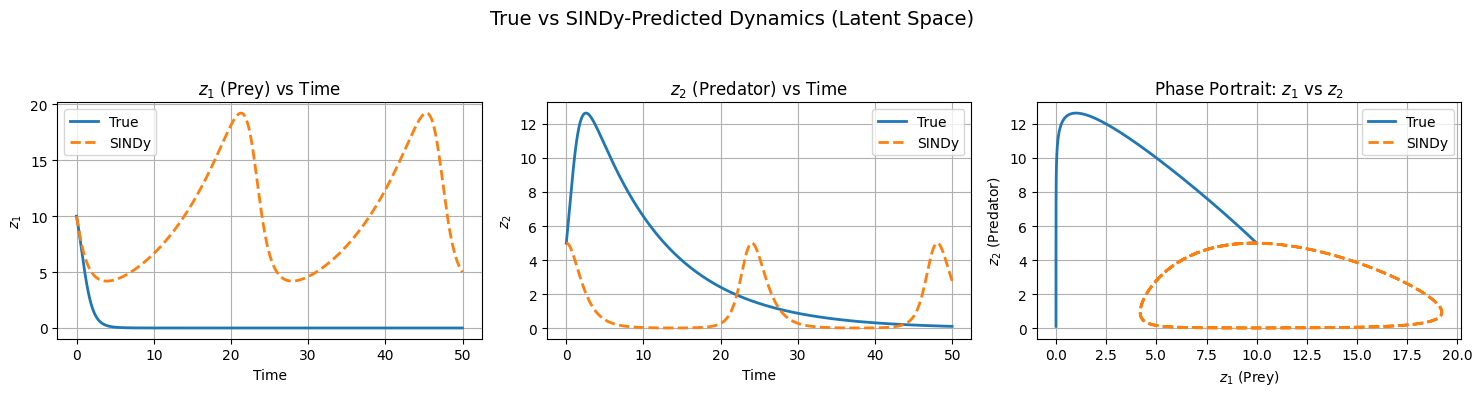

In [13]:
import matplotlib.pyplot as plt
from sindy_utils import sindy_simulate
from scipy.integrate import odeint
import numpy as np

# Time vector
t = np.arange(0, 50, 0.02)

# Initial condition (normalized)
z0 = np.array([10.0, 5.0])  # normalize to match training

# True Lotka-Volterra simulation
def lotka_volterra(z, t, alpha=0.1, beta=0.1, delta=0.1, gamma=0.1):
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# SINDy simulation
true_dynamics = sindy_simulate(z0, t, Xi_true, poly_order=3, include_sine=False)
pred_dynamics = sindy_simulate(z0, t, Xi, poly_order=3, include_sine=False)

# --- Plotting ---
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# z1(t)
axs[0].plot(t, true_dynamics[:, 0], label="True", linewidth=2)
axs[0].plot(t, pred_dynamics[:, 0], '--', label="SINDy", linewidth=2)
axs[0].set_title(r"$z_1$ (Prey) vs Time")
axs[0].set_xlabel("Time")
axs[0].set_ylabel(r"$z_1$")
axs[0].legend()
axs[0].grid(True)

# z2(t)
axs[1].plot(t, true_dynamics[:, 1], label="True", linewidth=2)
axs[1].plot(t, pred_dynamics[:, 1], '--', label="SINDy", linewidth=2)
axs[1].set_title(r"$z_2$ (Predator) vs Time")
axs[1].set_xlabel("Time")
axs[1].set_ylabel(r"$z_2$")
axs[1].legend()
axs[1].grid(True)

# Phase portrait: z1 vs z2
axs[2].plot(true_dynamics[:, 0], true_dynamics[:, 1], label="True", linewidth=2)
axs[2].plot(pred_dynamics[:, 0], pred_dynamics[:, 1], '--', label="SINDy", linewidth=2)
axs[2].set_title("Phase Portrait: $z_1$ vs $z_2$")
axs[2].set_xlabel(r"$z_1$ (Prey)")
axs[2].set_ylabel(r"$z_2$ (Predator)")
axs[2].legend()
axs[2].grid(True)

plt.suptitle("True vs SINDy-Predicted Dynamics (Latent Space)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()
